# ЛР № 01. Основы языковых моделей

**Вариант:** студенческий  
**Учебный профиль:** Greenfield Town  
**Время:** 6 академических часов  
**Seed:** 42

Перед работой выберите один из равноправных маршрутов: [компактную лекцию](lecture_01_language_model_basics_compact.md) с доступным первым объяснением или [полный лонгрид](lecture_01_language_model_basics.md) с подробными разборами. Затем работайте с ячейками по порядку. Этот notebook оставляет рядом с кодом только то пояснение, которое нужно для очередного шага. После каждой части сформулируйте короткий вывод в Markdown-ячейке.

**Навигация:** [страница ЛР](README.md) · [компактная лекция](lecture_01_language_model_basics_compact.md) · [полный лонгрид](lecture_01_language_model_basics.md) · [Harbor example](lab_01_example.ipynb) · [student](lab_01_student.ipynb) · [teacher](lab_01_teacher.ipynb)


## Подготовка

Этот notebook читает единый активный профиль `Greenfield Town` из `data/greenfield_town.json` и не использует сеть.


In [14]:
from __future__ import annotations

from collections import Counter, defaultdict
from copy import deepcopy
import json
import math
import random
import re

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

from pathlib import Path

possible_lab_dirs = [Path.cwd(), Path.cwd() / "01-lab-language-model-basics"]
LAB_DIR = next((path for path in possible_lab_dirs if (path / "data" / "greenfield_town.json").is_file()), None)
if LAB_DIR is None:
    raise FileNotFoundError("Запустите notebook из корня проекта или каталога лабораторной работы.")

SCENARIO_PATH = LAB_DIR / "data" / "greenfield_town.json"
SCENARIO = json.loads(SCENARIO_PATH.read_text(encoding="utf-8"))
print(f"Активный профиль данных: {SCENARIO['title']}")


Активный профиль данных: Greenfield Town


## Как проходить этот notebook

**Профиль:** Greenfield Town. В student-варианте из кодовых ячеек самостоятельно дописывайте только ячейки с `TODO`; отдельные Markdown-ячейки ниже нужны для ваших письменных выводов.

1. Выполняйте §§1–6 строго сверху вниз: функции §1 нужны дальше, §2 использует BoW, §5 готовит PPL для §6.
2. Следующая ячейка после реализации — готовая контрольная проверка: запускайте её, но не переписывайте. Если она остановилась, исправьте текущую реализацию, а не переходите к следующему разделу.
3. §§1–2 образуют одну ветвь классификации документов. Skip-gram (§3), BPE (§4) и Count LM (§5) — самостоятельные учебные эксперименты, а не один конвейер; §6 оценивает их результаты разными способами.
4. Точные значения loss и ближайших слов могут немного отличаться между средами. Надёжные признаки готовности — форма тензора, диапазон числа, контрольное утверждение и объяснение ограничения метода.
5. После раздела заполните отдельную Markdown-ячейку ответа: назовите наблюдаемый вывод, причину и границу интерпретации.

Для теории можно выбрать [компактную лекцию](lecture_01_language_model_basics_compact.md) или [полный лонгрид](lecture_01_language_model_basics.md): это равноправные маршруты разной глубины.


## 1. Мешок слов и n-граммы

Для объяснения выберите §1 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). В этом шаге нужно превратить строку в список токенов, назначить каждому токену устойчивый индекс и построить бинарный вектор. BoW хранит присутствие токена, но не его позицию; n-граммы ниже покажут, какую часть порядка можно вернуть.


### Маршрут §1: от строки к признакам

**Зачем.** Следующие разделы не умеют читать строку напрямую: им нужны устойчивые номера слов и бинарные признаки документа.

**Где писать.** В следующей ячейке с четырьмя незавершёнными функциями.

**Порядок.** 1) привести текст к нижнему регистру и выделить английские слова; 2) собрать уникальные токены всех документов и отсортировать их; 3) создать нулевой вектор длины словаря и поставить единицы только известным словам документа; 4) пройти по списку токенов скользящими окнами длины `n`.

**Не меняйте.** Данные профиля, порядок классов и контрольную ячейку после реализации.

**Что запустить.** Сразу следующую ячейку с DTM и тепловой картой.

**Готово, если.** В Greenfield Town напечатаны словарь из 51 токенов и DTM `12 × 51`; BoW двух переставленных фраз совпадают, но их биграммы различаются.

**Если не получилось.** Проверьте, что BoW бинарный: повтор слова не создаёт `2`, а OOV-слово не получает новый индекс. Если DTM имеет другую ширину, словарь должен строиться один раз по всем документам.

**Что записать.** Наблюдение о разреженности, причина потери порядка и роль биграмм.


In [15]:
def tokenize(text: str) -> list[str]:
    """Верните список строчных английских слов без пунктуации."""
    return re.findall(r"[a-z]+", text.lower())


def build_vocabulary(texts: list[str]) -> dict[str, int]:
    """Верните словарь «токен -> индекс» с алфавитным порядком токенов."""
    tokens = set()
    for text in texts:
        tokens.update(tokenize(text))
    return {token: idx for idx, token in enumerate(sorted(tokens))}


def doc_to_bow(text: str, vocabulary: dict[str, int]) -> list[int]:
    """Верните бинарный BoW-вектор длины len(vocabulary)."""
    vector = [0] * len(vocabulary)
    for token in tokenize(text):
        idx = vocabulary.get(token)
        if idx is not None:
            vector[idx] = 1
    return vector


def make_ngrams(tokens: list[str], n: int) -> list[tuple[str, ...]]:
    """Все последовательные n-граммы."""
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

Размер словаря: 51
Форма DTM: (12, 51); плотность: 0.113


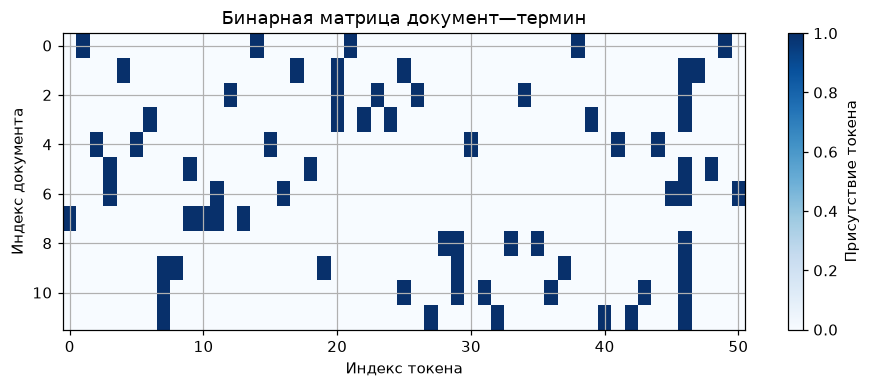

BoW совпадают: True
Биграммы первой фразы: [('garden', 'gate'), ('gate', 'opens')]
Биграммы второй фразы: [('opens', 'gate'), ('gate', 'garden')]


In [16]:
classification_data = SCENARIO["classification"]
CLASS_NAMES = classification_data["class_names"]
DOCS = [record["text"] for record in classification_data["documents"]]
class_to_id = {class_name: index for index, class_name in enumerate(CLASS_NAMES)}
LABELS = torch.tensor(
    [class_to_id[record["label"]] for record in classification_data["documents"]],
    dtype=torch.long,
)

vocabulary = build_vocabulary(DOCS)
document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in DOCS], dtype=torch.float32)
density = float(document_vectors.mean())
print(f"Размер словаря: {len(vocabulary)}")
print(f"Форма DTM: {tuple(document_vectors.shape)}; плотность: {density:.3f}")

fig, ax = plt.subplots(figsize=(10, 3.5))
dtm_image = ax.imshow(document_vectors.numpy(), aspect="auto", cmap="Blues")
ax.set_xlabel("Индекс токена")
ax.set_ylabel("Индекс документа")
ax.set_title("Бинарная матрица документ—термин")
fig.colorbar(dtm_image, ax=ax, label="Присутствие токена")
plt.show()

first_text, second_text = classification_data["order_examples"]
first = tokenize(first_text)
second = tokenize(second_text)
order_vocabulary = build_vocabulary([first_text, second_text])
print("BoW совпадают:", doc_to_bow(first_text, order_vocabulary) == doc_to_bow(second_text, order_vocabulary))
print("Биграммы первой фразы:", make_ngrams(first, 2))
print("Биграммы второй фразы:", make_ngrams(second, 2))


**Вывод 1.** Почему DTM разрежена? Какой смысловой признак теряет BoW? Почему биграммы не являются универсальным решением?


### Ответ студента 1

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Почему DTM разрежена, какой признак теряет BoW, что возвращают биграммы и почему они не являются универсальным решением?


## 2. Softmax, кросс-энтропия и классификатор

Для объяснения выберите §2 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Контрольная ячейка показывает, как логиты превращаются в вероятности; затем ваша модель должна вернуть именно логиты. Убедитесь, что входные признаки имеют тип `float32`, метки — `torch.long`, а `Softmax` не добавлен в `forward`.


![Схема выходного слоя](assets/output_layer.png)

*Рисунок 1. Элементы выходного слоя формируют логиты для классов.*


### Маршрут §2.1: сначала ручная математика, затем проверка

**Зачем.** Softmax превращает три сравнительных логита в три вероятностные оценки, а кросс-энтропия показывает, насколько мало вероятности получила правильная метка.

**Где записать ответ.** В следующей Markdown-ячейке «Ответ студента 2.1», до запуска контрольного кода.

**Порядок.** Для логитов `(2.0, 1.0, 0.5)` отдельно найдите `exp(2.0)`, `exp(1.0)`, `exp(0.5)`; сложите их; разделите каждую экспоненту на сумму; для первого правильного класса возьмите `-log(p_0)`.

**Не меняйте.** Контрольную ячейку, её логиты и индекс правильного класса: она нужна для сравнения ручного результата с `torch.softmax` и `CrossEntropyLoss`.

**Готово, если.** Вероятности приблизительно равны `(0.629, 0.231, 0.140)`, их сумма равна `1`, а потеря около `0.464`.

**Если не получилось.** Проверьте, что делите каждую экспоненту на общую сумму трёх экспонент, а логарифм берёте от вероятности первого класса, а не от логита `2.0`.

**Что записать.** Три экспоненты, их сумму, три вероятности и `-log(p_0)` — в шаблон ответа непосредственно ниже.


### Шаг 2.1. Ручная проверка softmax и кросс-энтропии

До запуска контрольной ячейки вручную вычислите softmax для логитов `(2.0, 1.0, 0.5)`: сначала найдите три экспоненты, затем их сумму и три вероятности. Проверьте, что вероятности дают единицу. Если верен первый класс, вычислите `-log(p_0)` и кратко объясните, почему это кросс-энтропия. После этого запустите ячейку и сравните ручной результат с `torch.softmax` и `nn.CrossEntropyLoss`.


### Ответ студента 2.1

- `exp(2.0)`, `exp(1.0)`, `exp(0.5)`:
- Их сумма:
- Softmax с точностью до трёх знаков:
- `-log(p_0)`:
- Почему это совпадает с кросс-энтропией первого правильного класса:


Softmax: [0.6285 0.2312 0.1402]
Сумма вероятностей: 1.000000
Потеря вручную: 0.464369; PyTorch: 0.464369
Softmax не меняется после общего сдвига логитов: True


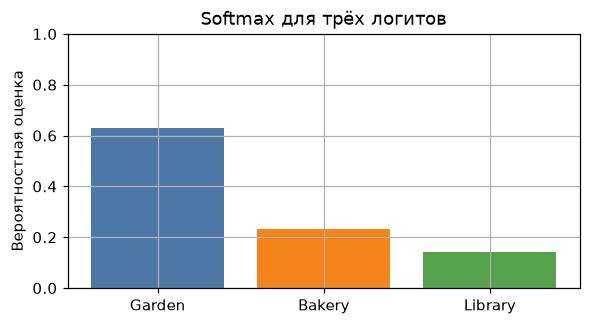

In [17]:
logits_example = torch.tensor([2.0, 1.0, 0.5])
probabilities_example = torch.softmax(logits_example, dim=0)
manual_loss = -math.log(float(probabilities_example[0]))
torch_loss = nn.CrossEntropyLoss()(logits_example.unsqueeze(0), torch.tensor([0]))
shifted_probabilities = torch.softmax(logits_example + 10.0, dim=0)
print("Softmax:", probabilities_example.numpy().round(4))
print(f"Сумма вероятностей: {probabilities_example.sum():.6f}")
print(f"Потеря вручную: {manual_loss:.6f}; PyTorch: {torch_loss.item():.6f}")
print("Softmax не меняется после общего сдвига логитов:", torch.allclose(probabilities_example, shifted_probabilities))
assert torch.isclose(probabilities_example.sum(), torch.tensor(1.0))
assert math.isclose(manual_loss, torch_loss.item(), rel_tol=1e-6)
assert torch.allclose(probabilities_example, shifted_probabilities)

plt.figure(figsize=(6, 3))
plt.bar(CLASS_NAMES, probabilities_example.numpy(), color=["#4c78a8", "#f58518", "#54a24b"])
plt.ylim(0, 1)
plt.ylabel("Вероятностная оценка")
plt.title("Softmax для трёх логитов")
plt.show()


### Шаг 2.2. Обучение и чтение результата классификатора

Реализуйте `SimpleClassifier`: первый `Linear` должен переводить `input_dim` в `hidden_dim`, `ReLU` не меняет форму, а второй `Linear` переводит `hidden_dim` в число классов. В `forward` верните логиты без `Softmax`. Затем запустите ячейку обучения и запишите начальную и финальную потерю, форму `new_document_logits` и объяснение: `argmax(dim=1)` выбирает класс отдельно для каждого документа.


### Маршрут §2.2: собрать и проверить классификатор

**Зачем.** Классификатор должен по одной BoW-строке выбрать один из классов `Garden`, `Bakery`, `Library`.

**Где писать.** В следующей ячейке класса `SimpleClassifier`; цикл обучения ниже уже готов и его менять не нужно.

**Порядок.** В конструкторе создайте первый линейный слой от длины BoW к 24 скрытым признакам, ReLU и второй линейный слой к трём классам. В `forward` примените их слева направо и верните необработанные логиты.

**Не меняйте.** Не добавляйте Softmax в `forward`, не меняйте `torch.long` у меток и не переписывайте готовые 800 шагов обучения.

**Что запустить.** Следующую ячейку обучения и чтения новых документов.

**Готово, если.** Поток имеет форму `(12, 51) → (12, 24) → (12, 3)`, loss уменьшается, а `new_document_logits` имеет форму `(2, 3)`.

**Если не получилось.** Ошибка форм обычно означает, что `input_dim` не равен длине BoW. Ошибка типа метки означает, что `LABELS` должны иметь тип `torch.long`. `argmax(dim=1)` выбирает класс внутри каждой строки, а не между документами.

**Что записать.** Начальную и финальную loss, форму логитов, смысл `dim=1` и ограничение: уменьшение train loss не доказывает обобщение.


In [18]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

Форма classifier_model.fc1.weight: (24, 51)
Потеря: 1.0895 -> 0.0056
Формы потока: (12, 51) -> (12, 24) -> (12, 3)
Форма логитов: (2, 3)
fresh bread and cakes -> Bakery
readers visit the quiet library -> Library


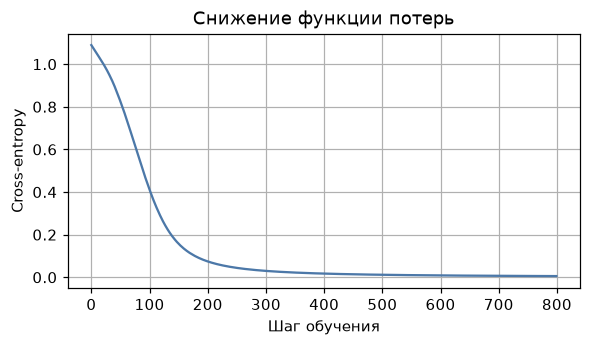

In [19]:
torch.manual_seed(SEED)
classifier_model = SimpleClassifier(input_dim=len(vocabulary), hidden_dim=24, output_dim=len(CLASS_NAMES))
print("Форма classifier_model.fc1.weight:", tuple(classifier_model.fc1.weight.shape))
assert tuple(classifier_model.fc1.weight.shape) == (24, len(vocabulary))
criterion = nn.CrossEntropyLoss()
classifier_optimizer = torch.optim.SGD(classifier_model.parameters(), lr=0.05)
classifier_losses = []
classifier_model.train()
for _ in range(800):
    classifier_optimizer.zero_grad()
    logits = classifier_model(document_vectors)
    classifier_loss = criterion(logits, LABELS)
    classifier_loss.backward()
    classifier_optimizer.step()
    classifier_losses.append(float(classifier_loss.detach()))

classifier_model.eval()
NEW_DOCS = classification_data["new_documents"]
new_document_vectors = torch.tensor([doc_to_bow(doc, vocabulary) for doc in NEW_DOCS], dtype=torch.float32)
with torch.no_grad():
    hidden_vectors = classifier_model.relu(classifier_model.fc1(document_vectors))
    new_document_logits = classifier_model(new_document_vectors)
    predicted_ids = torch.argmax(new_document_logits, dim=1)
print(f"Потеря: {classifier_losses[0]:.4f} -> {classifier_losses[-1]:.4f}")
print("Формы потока:", tuple(document_vectors.shape), "->", tuple(hidden_vectors.shape), "->", (len(DOCS), len(CLASS_NAMES)))
print("Форма логитов:", tuple(new_document_logits.shape))
assert tuple(hidden_vectors.shape) == (len(DOCS), 24)
assert tuple(new_document_logits.shape) == (len(NEW_DOCS), len(CLASS_NAMES))
for document, class_id in zip(NEW_DOCS, predicted_ids.tolist()):
    print(f"{document} -> {CLASS_NAMES[class_id]}")

plt.figure(figsize=(6, 3))
plt.plot(classifier_losses, color="#4c78a8")
plt.xlabel("Шаг обучения")
plt.ylabel("Cross-entropy")
plt.title("Снижение функции потерь")
plt.show()


**Вывод 2.** Почему в `forward` не нужен отдельный `Softmax`? Укажите форму `new_document_logits` и объясните роль `dim=1` в `argmax`.


### Ответ студента 2

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Как изменилась loss, какую форму имеют новые логиты, что выбирает `argmax(dim=1)` и почему Softmax не нужен в `forward`?


## 3. Skip-gram и эмбеддинги

Для объяснения выберите §3 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Сначала создайте направленные пары «центр — контекст», затем передайте индексы центральных слов в `nn.Embedding` и предскажите индекс контекста. Слой хранит плотный вектор для каждого токена; это статическое представление, поэтому разные значения одного слова не разделяются.


![Схема skip-gram](assets/skip_gram.png)

*Рисунок 2. Центральный токен отображается в плотный вектор, из которого предсказывается контекст.*


### Маршрут §3: от соседей слова к эмбеддингам

**Зачем.** Skip-gram учит плотный вектор слова по его соседям, поэтому можно сравнить локальные окружения, а не только совпадение букв.

**Где писать.** В следующей ячейке: сначала функция пар, затем класс `SkipGramModel`, затем `nearest_words`.

**Порядок.** 1) для каждого центрального токена перечислите все токены окна радиуса 2, кроме него самого; 2) создайте слой `nn.Embedding` и линейный выход к размеру словаря; 3) в `forward` получите embedding центра и логиты контекста; 4) нормируйте все строки векторов, вычислите косинусные оценки и исключите само слово-запрос.

**Не меняйте.** Корпус, seed, готовый цикл обучения и число ближайших соседей.

**Что запустить.** Следующую ячейку, которая создаёт индексы, обучает модель и рисует двумерную проекцию.

**Готово, если.** Получено 196 направленных пар; поток имеет вид `center_ids (196,) → embedding (196, 12) → logits (196, 33)`; для `gardener` выведены три соседа, но само слово не попало в этот список.

**Если не получилось.** Самопара означает, что не исключен индекс центра. Ошибка размера выходного слоя означает, что он должен иметь столько выходов, сколько токенов в `embedding_vocabulary`. Положение точек на PCA-графике не является буквальной картой значений слов.

**Что записать.** Один наблюдаемый сосед, общий локальный контекст и ограничение малого корпуса.


In [20]:
def make_skipgram_pairs(tokens: list[str], window_size: int) -> list[tuple[str, str]]:
    pairs = []
    for i, center in enumerate(tokens):
        lo = max(0, i - window_size)
        hi = min(len(tokens), i + window_size + 1)
        for j in range(lo, hi):
            if j == i:
                continue
            pairs.append((center, tokens[j]))
    return pairs


class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, center_ids: torch.Tensor) -> torch.Tensor:
        emb = self.embeddings(center_ids)
        logits = self.output(emb)
        return logits


def nearest_words(word: str, vocabulary: dict[str, int], vectors: torch.Tensor, top_k: int = 3):
    idx = vocabulary[word]
    norms = vectors.norm(dim=1, keepdim=True).clamp_min(1e-8)
    normalized = vectors / norms
    query = normalized[idx]
    similarities = normalized @ query
    similarities[idx] = -float("inf")
    top_indices = torch.topk(similarities, k=top_k).indices.tolist()
    inv_vocab = {i: w for w, i in vocabulary.items()}
    return [inv_vocab[i] for i in top_indices]

In [21]:
embedding_data = SCENARIO["embedding"]
embedding_lines = embedding_data["lines"]
embedding_tokens = [token for line in embedding_lines for token in tokenize(line)]
embedding_vocabulary = build_vocabulary(embedding_lines)
skipgram_pairs = [
    pair
    for line in embedding_lines
    for pair in make_skipgram_pairs(tokenize(line), window_size=embedding_data["window_size"])
]
center_ids = torch.tensor([embedding_vocabulary[center] for center, _ in skipgram_pairs], dtype=torch.long)
context_ids = torch.tensor([embedding_vocabulary[context] for _, context in skipgram_pairs], dtype=torch.long)
print(f"Токенов: {len(embedding_tokens)}; пар: {len(skipgram_pairs)}; словарь: {len(embedding_vocabulary)}")
print("Первые направленные пары:", skipgram_pairs[:6])
assert all(center != context for center, context in skipgram_pairs)

torch.manual_seed(SEED)
skipgram_model = SkipGramModel(len(embedding_vocabulary), embedding_dim=embedding_data["embedding_dim"])
skipgram_optimizer = torch.optim.Adam(skipgram_model.parameters(), lr=embedding_data["learning_rate"])
skipgram_model.train()
for _ in range(embedding_data["steps"]):
    skipgram_optimizer.zero_grad()
    skipgram_loss = nn.CrossEntropyLoss()(skipgram_model(center_ids), context_ids)
    skipgram_loss.backward()
    skipgram_optimizer.step()

skipgram_model.eval()
embeddings = skipgram_model.embedding.weight.detach()
for query_word in embedding_data["query_words"]:
    print(f"Ближайшие слова к {query_word!r}:", [(word, round(score, 3)) for word, score in nearest_words(query_word, embedding_vocabulary, embeddings)])

matrix = embeddings.numpy()
centered = matrix - matrix.mean(axis=0, keepdims=True)
_, _, right_vectors = np.linalg.svd(centered, full_matrices=False)
coordinates = centered @ right_vectors[:2].T
inverse_embedding_vocabulary = {index: token for token, index in embedding_vocabulary.items()}
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(coordinates[:, 0], coordinates[:, 1], color="#4c78a8")
for index, point in enumerate(coordinates):
    ax.annotate(inverse_embedding_vocabulary[index], point, xytext=(4, 4), textcoords="offset points")
ax.set_title("Двумерная проекция учебных эмбеддингов")
ax.set_xlabel("Первая главная компонента")
ax.set_ylabel("Вторая главная компонента")
plt.show()


Токенов: 67; пар: 196; словарь: 33
Первые направленные пары: [('the', 'gardener'), ('the', 'waters'), ('gardener', 'the'), ('gardener', 'waters'), ('gardener', 'the'), ('waters', 'the')]


AttributeError: 'SkipGramModel' object has no attribute 'embedding'

![Пространство эмбеддингов](assets/embedding_space.png)

*Рисунок 3. Двумерная проекция помогает сравнивать направления и расстояния между векторами.*


        **Вывод 3.** Назовите один наблюдаемый близкий вектор и объясните, почему малый учебный корпус не позволяет делать общие выводы о значениях слов.


### Ответ студента 3

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Какой сосед слова вы наблюдали, что в их контекстах похоже и почему этого недостаточно для общего вывода?


## 4. Подсловная токенизация BPE

Для объяснения выберите §4 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Эта символьная учебная BPE начинает с символов, считает соседние пары и последовательно сливает самые частые. Сохраняйте различие между частотой слова, частотой пары и упорядоченным списком `merges`; префикс `_` отмечает начало слова, а неизвестный символ заменяется на `<UNK>`.


### Маршрут §4: обучить и применить BPE

**Зачем.** Символьный BPE помогает представить новую словоформу как известные части, когда цельного слова нет в словаре.

**Где писать.** В следующей ячейке с пятью BPE-функциями — реализуйте их сверху вниз.

**Порядок.** 1) сохраните каждую словоформу как символы с `_` в начале и её частоту; 2) посчитайте соседние пары с весом частоты словоформы; 3) замените только точные соседние токены выбранной пары; 4) повторяйте подсчёт и слияние до лимита словаря; 5) при применении добавьте `_`, замените неизвестный символ на `<UNK>` и исполните `merges` по порядку.

**Не меняйте.** Лимит `50`, порядок уже выученных `merges` и контрольную ячейку.

**Что запустить.** Следующую ячейку, которая печатает первые правила и сегментации.

**Готово, если.** Число BPE-токенов не больше 50; слово `garden7` содержит `<UNK>` в результате сегментации.

**Если не получилось.** `_` обозначает начало слова. `<UNK>` — неизвестный символ BPE; `<unk>` строчными буквами появится только в Count LM как неизвестная цель. Если правила дают другой результат, проверьте, что они применяются в исходном порядке.

**Что записать.** Почему частота целой словоформы влияет на пару, что показывает `<UNK>` и почему порядок правил важен.


In [ ]:
from collections import Counter
import re


def initialize_vocabulary(corpus: list[str]):
    """Словоформа -> частота, словоформа хранится как '_ s y m b o l s'."""
    word_counts = Counter(corpus)
    vocab = {}
    for word, count in word_counts.items():
        chars = " ".join("_" + word)   # '_h a r b o r'
        vocab[chars] = count
    return vocab


def get_pair_counts(vocabulary: dict[str, int]):
    """Соседние пары токенов с весом = частота словоформы."""
    pairs = Counter()
    for word, freq in vocabulary.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i + 1])] += freq
    return pairs


def merge_pair(vocabulary: dict[str, int], pair: tuple[str, str]):
    """Слить только полные соседние токены пары."""
    a, b = pair
    pattern = re.compile(
        r"(?<!\S)" + re.escape(a) + r" " + re.escape(b) + r"(?!\S)"
    )
    new_vocab = {}
    for word, freq in vocabulary.items():
        new_word = pattern.sub(a + b, word)
        new_vocab[new_word] = freq
    return new_vocab


def byte_pair_encoding(corpus: list[str], vocab_size: int):
    """Учим merges, пока не достигнем vocab_size или не кончатся пары."""
    vocab = initialize_vocabulary(corpus)
    merges = []
    while True:
        pairs = get_pair_counts(vocab)
        if not pairs:
            break

        total_symbols = sum(len(set(w.split())) for w in vocab)
        if total_symbols >= vocab_size:
            break

        best_pair, _ = pairs.most_common(1)[0]
        vocab = merge_pair(vocab, best_pair)
        merges.append(best_pair)
    return merges


def tokenize_word(
    word: str,
    merges: list[tuple[str, str]],
    charset: set[str],
    unk_token: str = "<UNK>",
):
    """Применить BPE к одному слову: '_' + <UNK> + merges по порядку."""
    symbols = []
    for i, ch in enumerate(word):
        if ch not in charset:
            token = unk_token
        else:
            token = "_" + ch if i == 0 else ch
        symbols.append(token)

    for a, b in merges:
        i = 0
        while i < len(symbols) - 1:
            if symbols[i] == a and symbols[i + 1] == b:
                symbols[i:i + 2] = [a + b]
            else:
                i += 1
    return symbols

In [ ]:
bpe_data = SCENARIO["bpe"]
bpe_corpus = [token for text in bpe_data["corpus"] for token in tokenize(text)]
bpe_vocabulary, merges, charset, bpe_tokens = byte_pair_encoding(bpe_corpus, bpe_data["vocab_size"])
print(f"Размер начального алфавита: {len(charset)}")
print(f"Размер словаря BPE: {len(bpe_tokens)}; число слияний: {len(merges)}")
print("Шаг | сливаемая пара")
for step, pair in enumerate(merges[:10], start=1):
    print(f"{step:3d} | {pair[0]!r} + {pair[1]!r}")
for word in bpe_data["probe_words"]:
    print(f"{word:18s} -> {tokenize_word(word, merges, charset)}")
assert len(bpe_tokens) <= bpe_data["vocab_size"]
assert "<UNK>" in tokenize_word(bpe_data["probe_words"][-1], merges, charset)


ValueError: not enough values to unpack (expected 4, got 0)

**Вывод 4.** Почему частота пары должна учитывать частоту всего слова? Как `<UNK>` влияет на токенизацию тестового слова с неизвестным символом? Почему порядок `merges` нельзя произвольно менять?


### Ответ студента 4

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Как частота словоформы влияет на BPE, что означает `<UNK>` и почему нельзя менять порядок `merges`?


## 5. Счётная триграммная языковая модель

Для объяснения выберите §5 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Триграмма оценивает следующее слово по двум предыдущим. Реализуйте отдельно хранение частот, поиск самого длинного доступного контекста и сглаженную вероятность; не смешивайте общий смысл $P$, несглаженную оценку $P_{\mathrm{MLE}}$ и реализованную $P_{+1}$.


### Маршрут §5: посчитать продолжения и вероятность

**Зачем.** Count LM отвечает на вопрос: какое слово чаще всего продолжает левый контекст и с какой сглаженной вероятностью?

**Где писать.** В следующей ячейке: сначала конструктор, затем `train`, прогноз, вероятность, генерация и PPL.

**Порядок.** 1) создайте отдельные словари счётчиков для униграмм, биграмм и триграмм; 2) в `train` заполните их скользящими окнами; 3) для прогноза ищите контекст длины 2, затем 1, затем 0; 4) для жадного выбора используйте сырые частоты; 5) для `get_probability` и PPL примените add-one сглаживание; 6) при генерации добавляйте найденный токен к текущей истории.

**Не меняйте.** `n=3`, токены train/test и готовую проверочную ячейку.

**Что запустить.** Следующую ячейку с известным и незнакомым контекстом, нормировкой и жадным продолжением.

**Готово для §5, если.** Контекст `['the', 'garden']` продолжается словом `gate`; сумма сглаженных вероятностей равна 1, неизвестная цель имеет положительную вероятность. Конечную PPL проверьте первой ячейкой §6: она использует эти же вероятности на отдельной тестовой последовательности.

**Если не получилось.** Незнакомый контекст запускает backoff, а неизвестная цель заменяется на `<unk>`; это разные случаи. Не используйте сглаженные вероятности для `predict_next_token`: он читает самый частый токен из `Counter`.

**Что записать.** Порядок backoff, роль сглаживания для PPL и ограничение: триграмма видит не более двух предыдущих слов.


In [ ]:
from collections import Counter, defaultdict


class CountLanguageModel:
    def __init__(self, n: int):
        self.n = n
        # counts[k] — словарь context_tuple -> Counter(next_token -> count),
        # где k = длина контекста (0 для униграмм, 1 для биграмм, 2 для триграмм...)
        self.counts = [defaultdict(Counter) for _ in range(n)]
        self.vocabulary: set[str] = set()

    def predict_next_token(self, context: list[str] | tuple[str, ...]):
        """Ищем самый длинный доступный контекст, затем откатываемся к униграммам."""
        context = tuple(context)

        # от самого длинного контекста к пустому
        for k in range(min(self.n - 1, len(context)), -1, -1):
            ctx = context[len(context) - k:] if k > 0 else ()
            if ctx in self.counts[k] and self.counts[k][ctx]:
                return self.counts[k][ctx].most_common(1)[0][0]
        return None

    def get_probability(self, token: str, context: list[str] | tuple[str, ...]) -> float:
        """Лапласово сглаживание по самому длинному наблюдённому контексту."""
        if token not in self.vocabulary:
            token = "<unk>"

        context = tuple(context)
        vocab_size = len(self.vocabulary)

        # ищем самый длинный контекст, который наблюдался
        for k in range(min(self.n - 1, len(context)), -1, -1):
            ctx = context[len(context) - k:] if k > 0 else ()
            if ctx in self.counts[k]:
                counter = self.counts[k][ctx]
                total = sum(counter.values())
                count = counter.get(token, 0)
                return (count + 1) / (total + vocab_size)
        # контекст вообще не наблюдался — тоже сглаживание
        return 1.0 / vocab_size


def train(model: CountLanguageModel, tokens: list[str]) -> None:
    """Заполняем частоты n-грамм для n = 1..model.n."""
    model.vocabulary = set(tokens) | {"<unk>"}

    for k in range(model.n):                       # k = длина контекста
        counter_for_k = model.counts[k]
        for i in range(k, len(tokens)):
            ctx = tuple(tokens[i - k:i]) if k > 0 else ()
            next_token = tokens[i]
            counter_for_k[ctx][next_token] += 1


def generate_text(model: CountLanguageModel, context: list[str], num_tokens: int) -> str:
    """Жадно добавляем предсказанные токены."""
    context = list(context)
    for _ in range(num_tokens):
        next_token = model.predict_next_token(context)
        if next_token is None:
            break
        context.append(next_token)
    return " ".join(context)


def compute_perplexity(
    model: CountLanguageModel,
    tokens: list[str],
    context_size: int,
) -> float:
    """exp( -mean( log P(token | context) ) )."""
    import math

    log_probs = []
    for i in range(context_size, len(tokens)):
        ctx = tokens[i - context_size:i]
        prob = model.get_probability(tokens[i], ctx)
        log_probs.append(math.log(prob))

    if not log_probs:
        return float("inf")
    mean_log = sum(log_probs) / len(log_probs)
    return math.exp(-mean_log)

In [ ]:
lm_data = SCENARIO["language_model"]
lm_train_tokens = tokenize(lm_data["train_text"])
lm_test_tokens = tokenize(lm_data["test_text"])

count_lm = CountLanguageModel(n=lm_data["n"])
train(count_lm, lm_train_tokens)
known_context = lm_data["known_context"]
unknown_context = lm_data["unknown_context"]
print("Знакомый контекст:", known_context, "->", count_lm.predict_next_token(known_context))
print("Незнакомый контекст:", unknown_context, "->", count_lm.predict_next_token(unknown_context))
print("P(unknown | unseen context) =", f"{count_lm.get_probability('unknown', unknown_context):.8f}")
probability_sum = sum(count_lm.get_probability(token, known_context) for token in count_lm.vocabulary)
print(f"Сумма P(token | знакомый контекст): {probability_sum:.12f}")
print("Продолжение:", generate_text(count_lm, lm_data["generation_context"], lm_data["generation_length"]))
assert count_lm.get_probability("unknown", unknown_context) > 0
assert math.isclose(probability_sum, 1.0, rel_tol=1e-12, abs_tol=1e-12)


**Вывод 5.** Опишите порядок отступа к более короткому контексту (backoff). Почему сглаживание Лапласа важно для перплексии? Назовите ограничение триграммной модели при работе с длинным текстом.


### Ответ студента 5

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Как срабатывает backoff, зачем нужно сглаживание и какой контекст триграмма не умеет хранить?


## 6. Перплексия, ROUGE и Elo

Для объяснения выберите §6 [компактной лекции](lecture_01_language_model_basics_compact.md) или [полного лонгрида](lecture_01_language_model_basics.md). Перплексия оценивает вероятность тестовых токенов, ROUGE — перекрытие с эталоном, а Elo — попарное предпочтение. Сначала назовите входы и диапазон каждой метрики: эти числа отвечают на разные вопросы и не заменяют друг друга.


In [ ]:
perplexity = compute_perplexity(count_lm, lm_test_tokens, context_size=count_lm.n - 1)
print(f"Перплексия на тестовой последовательности: {perplexity:.2f}")
assert math.isfinite(perplexity)


### Маршрут §6: измерить разные стороны качества

**Зачем.** PPL, ROUGE, Лайкерт и Elo отвечают на разные вопросы; одной цифрой качество текста здесь не измеряется.

**Где писать.** В следующей ячейке с метриками; реализуйте функции в порядке их объявления.

**Порядок.** 1) токенизируйте кандидат и эталон, сформируйте `Counter` n-грамм; 2) для ROUGE-N сложите минимумы кратностей; 3) для LCS заполните таблицу динамического программирования; 4) соедините точность и полноту в ROUGE-L; 5) вычислите ожидаемый балл Elo; 6) обновите оба рейтинга из ожиданий до изменения пары.

**Не меняйте.** Эталон, кандидаты, журнал матчей, `beta=8` и начальные рейтинги 1500.

**Что запустить.** Следующую ячейку с функциями метрик, а затем готовые ячейки ROUGE и Elo. PPL уже напечатана непосредственно выше.

**Готово, если.** PPL конечна; все ROUGE лежат в `[0, 1]`, кандидаты A и B дают разные значения, а сумма трёх Elo-рейтингов остаётся `4500`.

**Если не получилось.** `generated` — кандидат, `reference` — эталон. Повторы нужно учитывать через `min`, а не через множество. При Elo рассчитайте `expected_left` и `expected_right` до изменения рейтинга первого участника.

**Что записать.** Почему overlap не доказывает истинность; какую сильную сторону и какое ограничение имеет PPL; зачем нужны люди и почему Elo требует многих сравнений.


In [ ]:
from collections import Counter


def ngram_counter(text: str, n: int) -> Counter[tuple[str, ...]]:
    """Counter для всех n-грамм текста (токены — простой split)."""
    tokens = text.lower().split()
    if n <= 0 or len(tokens) < n:
        return Counter()
    return Counter(tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1))


def rouge_n_recall(generated: str, reference: str, n: int) -> float:
    """ROUGE-N recall: min(совпадений, сколько было в reference) / |reference|."""
    ref_ngrams = ngram_counter(reference, n)
    gen_ngrams = ngram_counter(generated, n)

    if not ref_ngrams:
        return 0.0

    overlap = 0
    for gram, ref_count in ref_ngrams.items():
        gen_count = gen_ngrams.get(gram, 0)
        overlap += min(ref_count, gen_count)

    return overlap / sum(ref_ngrams.values())


def lcs_length(left: list[str], right: list[str]) -> int:
    """Длина наибольшей общей подпоследовательности (классический ДП)."""
    m, n = len(left), len(right)
    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if left[i - 1] == right[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    return dp[m][n]


def rouge_l(generated: str, reference: str, beta: float = 8.0) -> float:
    """LCS-ориентированный ROUGE-L как F_beta-мера."""
    gen_tokens = generated.lower().split()
    ref_tokens = reference.lower().split()

    if not gen_tokens or not ref_tokens:
        return 0.0

    lcs = lcs_length(gen_tokens, ref_tokens)
    if lcs == 0:
        return 0.0

    precision = lcs / len(gen_tokens)
    recall = lcs / len(ref_tokens)

    beta_sq = beta ** 2
    return ((1 + beta_sq) * precision * recall) / (recall + beta_sq * precision)


def expected_score(rating_a: float, rating_b: float) -> float:
    """Ожидаемая вероятность победы A по шкале Elo."""
    return 1.0 / (1.0 + 10 ** ((rating_b - rating_a) / 400.0))


def update_elo(rating: float, actual_score: float, expected: float, k: float = 32) -> float:
    """Одно обновление рейтинга Elo."""
    return rating + k * (actual_score - expected)

In [ ]:
evaluation_data = SCENARIO["evaluation"]
reference = evaluation_data["reference"]
candidate_by_name = {item["name"]: item["text"] for item in evaluation_data["candidates"]}

rows = []
for name, candidate in candidate_by_name.items():
    rows.append((name, rouge_n_recall(candidate, reference, 1), rouge_n_recall(candidate, reference, 2), rouge_l(candidate, reference)))
print("Модель | ROUGE-1 | ROUGE-2 | ROUGE-L")
for name, r1, r2, rl in rows:
    print(f"{name:6s} | {r1:7.3f} | {r2:7.3f} | {rl:7.3f}")
assert all(0 <= value <= 1 for _, *values in rows for value in values)

names = [row[0] for row in rows]
x = np.arange(len(names))
plt.figure(figsize=(7, 3.5))
plt.bar(x - 0.25, [row[1] for row in rows], width=0.25, label="ROUGE-1")
plt.bar(x, [row[2] for row in rows], width=0.25, label="ROUGE-2")
plt.bar(x + 0.25, [row[3] for row in rows], width=0.25, label="ROUGE-L")
plt.xticks(x, ["Кандидат " + name for name in names])
plt.ylim(0, 1)
plt.ylabel("Полнота / F-мера")
plt.title("Сравнение текстов метриками ROUGE")
plt.legend()
plt.show()


In [ ]:
matches = [(left, right, float(left_score)) for left, right, left_score in evaluation_data["elo_matches"]]
ratings = {name: 1500.0 for name in evaluation_data["elo_names"]}
for left, right, left_score in matches:
    expected_left = expected_score(ratings[left], ratings[right])
    expected_right = 1 - expected_left
    ratings[left] = update_elo(ratings[left], left_score, expected_left)
    ratings[right] = update_elo(ratings[right], 1 - left_score, expected_right)
print("Итоговые Elo:")
for name, rating in sorted(ratings.items(), key=lambda item: item[1], reverse=True):
    print(f"{name}: {rating:.1f}")
assert math.isclose(sum(ratings.values()), 4500.0, rel_tol=1e-12)


### Шкала Лайкерта для ручной оценки

Оцените каждый текст по трём независимым критериям: связность, информативность и фактологическая точность.

| Балл | Интерпретация |
| ---: | --- |
| -2 | Критерий практически не выполнен. |
| -1 | Критерий выполнен с существенными недостатками. |
| 0 | Результат приемлем, но без убедительных достоинств. |
| 1 | Критерий выполнен хорошо. |
| 2 | Критерий выполнен полностью и убедительно. |

**Вывод 6.** Почему высокий ROUGE не доказывает фактологическую точность? Почему Elo требует многих попарных сравнений? Какую сильную сторону и какое ограничение имеет перплексия?


### Ответ студента 6

- Наблюдение из вывода:
- Почему результат получился:
- Ограничение метода:
- Ответ на вопрос: Почему ROUGE не доказывает истинность, какую сильную сторону и какое ограничение имеет PPL, что добавляет ручная оценка и почему Elo нельзя стабильно судить по одному матчу?

#### Ручная оценка Лайкерта кандидата A

Эти оценки не выводятся из ROUGE: для каждого критерия укажите собственное краткое обоснование по тексту кандидата.

| Критерий | Балл от -2 до 2 | Короткое обоснование |
| --- | ---: | --- |
| Связность | 2 | Грамматически корректно, порядок слов естественный, читается как цельная фраза. |
| Информативность | 1 | Все ключевые элементы сохранены (bell, rings, dawn), добавлено near harbor; акцент слегка переставлен. |
| Фактологическая точность | 2 | Полностью соответствует эталону по смыслу, лишних или ложных утверждений нет. |


## Итоговый практический результат: мини-портфолио текстового эксперимента

До этого места вы реализовали шесть связанных тем, но это не один искусственный конвейер: BPE, skip-gram и счётная языковая модель решают разные учебные задачи. Ниже готовая базовая ячейка собирает четыре самостоятельных результата в один понятный отчёт. Она использует готовые объекты предыдущих частей и запускается после их выполнения.

| Раздел лекции | Реализованный компонент | Что показывает итоговый отчёт | Проверка и граница вывода | Как переносить на похожую задачу |
| --- | --- | --- | --- | --- |
| §1 | `tokenize`, бинарный BoW, n-граммы | Токены, известные и OOV-слова, активные признаки и биграммы документа | Нулевой BoW означает отсутствие известных признаков; порядок и частоты не становятся признаками классификатора | Заменить документы, затем заново построить словарь и DTM |
| §2 | `SimpleClassifier` | Логиты, вероятности и тематический класс документа | Форма `(1, 3)`, сумма вероятностей равна 1; это не доказательство качества на новых данных | Подать новые документы и метки, затем переобучить модель |
| §3 | skip-gram и `nearest_words` | Три ближайших по косинусному сходству слова | Запрос не должен попасть в собственный список; близость относится только к малому корпусу | Заменить корпус контекстов и обучить эмбеддинги заново |
| §4 | символьный BPE | Разбиение нового слова на подслова и `<UNK>` для неизвестного символа | `<UNK>` — неизвестный символ BPE, а не неизвестное слово LM | Заменить корпус или размер словаря и обучить новые `merges` |
| §5 | счётная триграммная LM | Жадное продолжение, вероятность следующего токена и PPL тестовой последовательности | Конечная PPL использует teacher forcing; триграмма видит не более двух предыдущих токенов | Заменить обучающую и тестовую последовательности, затем обучить LM заново |
| §6 | PPL, ROUGE, Лайкерт и Elo | PPL, три ROUGE-значения, итог Elo и ручная оценка в паспорте | ROUGE не проверяет истинность, Лайкерт субъективен, Elo требует многих сравнений | Заменить кандидата, эталон и журнал сравнений; интерпретировать метрики вместе |

Полный результат — не только напечатанные числа. После базовой ячейки заполните паспорт: зафиксируйте наблюдение, проверку, ограничение и следующий безопасный шаг адаптации.


### Как завершить мини-портфолио

**Зачем.** Это не новая модель и не новая задача: отчёт собирает четыре уже реализованных результата, чтобы у каждого были вход, вывод, проверка и ограничение.

**Ваше действие.** Не изменяйте `PORTFOLIO_CASE` и `run_portfolio_case`; запустите готовую ячейку только после успешных §§1–6.

**Готово, если.** Напечатаны девять строк `✓`: форма логитов, нормировка softmax, известные признаки, запрос эмбеддингов, исключение самого слова, `<UNK>` BPE, конечная PPL, диапазон ROUGE и сумма Elo `4500`.

**Что записать.** В паспорте заполните все четыре строки по конкретному выводу отчёта. Укажите вход, наблюдаемый результат, проверенный инвариант, ограничение и одно действие для переноса на похожую задачу.

**Песочница.** Только после базового отчёта разрешено менять значения `CUSTOM_CASE`. Она проверяет OOV и пустой текст, не влияет на базовый результат и не заменяет обязательный паспорт.


In [ ]:
portfolio_data = SCENARIO["portfolio"]
PORTFOLIO_CASE = {
    **portfolio_data,
    "perplexity_tokens": lm_test_tokens,
    "candidate": candidate_by_name[portfolio_data["candidate_name"]],
    "reference": reference,
}


def as_tokens(value):
    '''Безопасно приводит строку или последовательность к учебным словным токенам.'''
    if isinstance(value, str):
        return tokenize(value)
    if isinstance(value, (list, tuple)):
        return [token for item in value for token in tokenize(str(item))]
    return []


def bounded_count(value, default=5):
    '''Не даёт необязательной песочнице случайно запросить слишком длинную генерацию.'''
    try:
        return min(max(int(value), 0), 20)
    except (TypeError, ValueError):
        return default


def run_portfolio_case(case, title, strict=False):
    '''Собирает отчёт, не меняя модель, словари, merges или исходные данные.'''
    document = str(case.get("document", ""))
    document_tokens = tokenize(document)
    known_tokens = sorted({token for token in document_tokens if token in vocabulary})
    oov_tokens = sorted({token for token in document_tokens if token not in vocabulary})
    document_bigrams = make_ngrams(document_tokens, 2)
    document_vector = torch.tensor([doc_to_bow(document, vocabulary)], dtype=torch.float32)

    if known_tokens:
        was_training = classifier_model.training
        classifier_model.eval()
        with torch.no_grad():
            document_logits = classifier_model(document_vector)
            document_probabilities = torch.softmax(document_logits, dim=1)
            document_class_id = int(torch.argmax(document_logits, dim=1).item())
        classifier_model.train(was_training)
        classification_message = "Класс выбран по известным бинарным признакам документа."
    else:
        document_logits = None
        document_probabilities = None
        document_class_id = None
        classification_message = "BoW нулевой: у модели нет лексического признака для содержательной классификации."

    query_tokens = as_tokens(case.get("embedding_word", ""))
    embedding_query = query_tokens[0] if len(query_tokens) == 1 else None
    if embedding_query in embedding_vocabulary:
        nearest = nearest_words(embedding_query, embedding_vocabulary, embeddings, top_k=3)
        embedding_message = "Запрос найден в словаре эмбеддингов."
    else:
        nearest = []
        embedding_message = "Запроса нет в словаре эмбеддингов: близкие слова не вычисляются."

    bpe_word = str(case.get("bpe_word", ""))
    if bpe_word:
        bpe_result = tokenize_word(bpe_word, merges, charset)
        bpe_message = "<UNK> здесь означает неизвестный символ, а не неизвестное слово языковой модели."
    else:
        bpe_result = []
        bpe_message = "Пустую строку сегментировать не нужно: в ней нет символов слова."

    lm_context = as_tokens(case.get("lm_context", []))
    num_tokens = bounded_count(case.get("num_tokens", 5))
    predicted_token = count_lm.predict_next_token(lm_context)
    predicted_probability = count_lm.get_probability(predicted_token, lm_context)
    generated_text = generate_text(count_lm, lm_context, num_tokens)
    ppl_tokens = as_tokens(case.get("perplexity_tokens", []))
    portfolio_ppl = compute_perplexity(count_lm, ppl_tokens, context_size=count_lm.n - 1)

    candidate = str(case.get("candidate", ""))
    portfolio_reference = str(case.get("reference", ""))
    rouge_scores = {
        "ROUGE-1": rouge_n_recall(candidate, portfolio_reference, 1),
        "ROUGE-2": rouge_n_recall(candidate, portfolio_reference, 2),
        "ROUGE-L": rouge_l(candidate, portfolio_reference),
    }
    elo_total = sum(ratings.values())
    elo_leader = max(ratings, key=ratings.get)

    report = {
        "classification": {
            "tokens": document_tokens,
            "known_tokens": known_tokens,
            "oov_tokens": oov_tokens,
            "active_features": int(document_vector.sum().item()),
            "logits_shape": tuple(document_logits.shape) if document_logits is not None else None,
            "probability_sum": float(document_probabilities.sum()) if document_probabilities is not None else None,
            "class_name": CLASS_NAMES[document_class_id] if document_class_id is not None else None,
            "message": classification_message,
        },
        "embeddings": {
            "query": embedding_query,
            "nearest": nearest,
            "message": embedding_message,
        },
        "bpe": {"word": bpe_word, "tokens": bpe_result},
        "language_model_and_metrics": {
            "context": lm_context,
            "predicted_token": predicted_token,
            "predicted_probability": predicted_probability,
            "generated_text": generated_text,
            "perplexity": portfolio_ppl,
            "rouge": rouge_scores,
            "elo_leader": elo_leader,
            "elo_total": elo_total,
        },
    }

    print(f"=== {title} ===")
    print("1. BoW + классификатор")
    print("   токены:", document_tokens)
    print("   известные / OOV:", known_tokens, "/", oov_tokens)
    print("   активные признаки:", report["classification"]["active_features"])
    if document_logits is not None:
        print("   logits:", tuple(document_logits.shape), "; вероятности:", document_probabilities[0].numpy().round(4))
        print("   предсказанный класс:", report["classification"]["class_name"])
    print("   ", classification_message)
    print("   биграммы для проверки порядка:", document_bigrams)

    print("2. Skip-gram")
    print("   запрос:", embedding_query)
    print("   ближайшие:", [(word, round(score, 3)) for word, score in nearest])
    print("   ", embedding_message)

    print("3. BPE")
    print(f"   {bpe_word!r} ->", bpe_result)
    print("   ", bpe_message)

    print("4. Count LM + метрики")
    print("   контекст:", lm_context, "->", predicted_token, f"(P={predicted_probability:.6f})")
    print("   жадное продолжение:", generated_text)
    print("   PPL тестовой последовательности:", portfolio_ppl)
    print("   ROUGE:", {name: round(score, 3) for name, score in rouge_scores.items()})
    print(f"   лидер Elo: {elo_leader}; сумма рейтингов: {elo_total:.1f}")

    if strict:
        checks = {
            "логиты имеют форму (1, 3)": report["classification"]["logits_shape"] == (1, 3),
            "вероятности классификатора суммируются к 1": report["classification"]["probability_sum"] is not None and math.isclose(report["classification"]["probability_sum"], 1.0, rel_tol=1e-6, abs_tol=1e-6),
            "базовый документ содержит известные признаки": bool(known_tokens),
            "слово-запрос известно эмбеддингам": embedding_query in embedding_vocabulary,
            "сам запрос исключён из списка соседей": all(word != embedding_query for word, _ in nearest),
            "BPE отмечает неизвестный символ": "<UNK>" in bpe_result,
            "PPL базового теста конечна": math.isfinite(portfolio_ppl),
            "все ROUGE лежат в [0, 1]": all(0 <= score <= 1 for score in rouge_scores.values()),
            "сумма Elo равна 4500": math.isclose(elo_total, 4500.0, rel_tol=1e-12),
        }
        print("Проверки обязательного базового сценария:")
        for check_name, passed in checks.items():
            print(f"   {'✓' if passed else '✗'} {check_name}")
        assert all(checks.values()), "Базовый мини-портфолио не прошёл одну из проверок."
    else:
        print("Диагностика песочницы: отличия от базового случая ожидаемы и не влияют на его проверки.")
    return report


BASELINE_PORTFOLIO = run_portfolio_case(PORTFOLIO_CASE, "Обязательный базовый мини-портфолио", strict=True)
BASELINE_PORTFOLIO_SNAPSHOT = deepcopy(BASELINE_PORTFOLIO)
PORTFOLIO_CASE_SNAPSHOT = deepcopy(PORTFOLIO_CASE)


NameError: name 'lm_test_tokens' is not defined

### Паспорт результата — обязательная часть сдачи

Заполните таблицу после успешного базового запуска. Не переписывайте теорию: опирайтесь на конкретные значения, напечатанные выше. В последней колонке назовите одно действие, которое вы действительно сделали бы при переносе на похожий набор данных.

| Блок результата | Вход и наблюдаемый результат | Проверенный инвариант | Ограничение вывода | Следующий шаг адаптации |
| --- | --- | --- | --- |
| BoW + классификатор |  |  |  |  |
| Skip-gram |  |  |  |  |
| BPE |  |  |  |  |
| Count LM + метрики |  |  |  |  |

Отдельно дайте для кандидата A три ручные оценки Лайкерта (`-2`…`2`): связность, информативность и фактологическая точность. Одним предложением объясните, почему эти оценки нельзя автоматически вывести из ROUGE.


### Необязательная песочница `CUSTOM_CASE`

Эта ячейка показывает безопасные границы интерфейса: полностью OOV-документ превращается в нулевой BoW, неизвестное слово не ищется среди эмбеддингов, а пустая тестовая последовательность имеет PPL `inf`. Базовый отчёт выше не меняется. Можно заменить только значения словаря `CUSTOM_CASE`; не меняйте функции и не включайте результат песочницы в обязательный паспорт, если это не требуется преподавателем.


In [ ]:
# Меняйте только значения этого словаря. Базовый профиль и обученные объекты выше не меняются.
CUSTOM_CASE = deepcopy(SCENARIO["sandbox"])

CUSTOM_PORTFOLIO = run_portfolio_case(CUSTOM_CASE, "Необязательная песочница", strict=False)
baseline_unchanged = BASELINE_PORTFOLIO == BASELINE_PORTFOLIO_SNAPSHOT and PORTFOLIO_CASE == PORTFOLIO_CASE_SNAPSHOT
assert baseline_unchanged
print("Песочница не меняет базовый результат и его входы:", baseline_unchanged)
